<a href="https://colab.research.google.com/github/lukwac123/computer_vision_course/blob/main/09_object-segmentation/02_mask_rcnn_tf2_current.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Mask R-CNN — detekcja i segmentacja obiektów (wersja współczesna)

Notebook jest aktualizacją ćwiczenia opartego pierwotnie na repozytorium Matterport `Mask_RCNN`,
TensorFlow 1.x i starym Keras.

### Wersja przygotowana dla współczesnego Google Colab
- Python 3.13
- TensorFlow 2.20+
- Keras 3.x
- bez `%tensorflow_version 1.x`
- bez `keras.engine`
- bez starego pakietu `mrcnn`

Zamiast niekompatybilnej implementacji Matterport używany jest **pretrenowany Mask R-CNN
Inception ResNet V2 1024x1024** w formacie TensorFlow SavedModel.

Cel ćwiczenia pozostaje taki sam:
1. wczytanie modelu Mask R-CNN,
2. wczytanie obrazu,
3. detekcja obiektów,
4. wyznaczenie masek instancji,
5. wizualizacja ramek, klas, prawdopodobieństw i masek.

> Oryginalny materiał kursowy: krakowiakpawel9 / e-smartdata.org.  
> Ten notebook jest techniczną adaptacją do aktualnego środowiska.


## 1. Sprawdzenie środowiska

In [ ]:

import sys
import os
import re
import tarfile
import urllib.request
import time

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
import keras

print("Python:    ", sys.version.split()[0])
print("TensorFlow:", tf.__version__)
print("Keras:     ", keras.__version__)

print("\nGPU:")
print(tf.config.list_physical_devices("GPU"))


Python:     3.13.15
TensorFlow: 2.20.0
Keras:      3.13.2

GPU:
[]



## 2. Katalogi robocze

Nie usuwamy całej zawartości `/content`, jak robił stary notebook.
Tworzymy osobny katalog dla tego ćwiczenia.


In [ ]:

ROOT_DIR = "/content/mask_rcnn_tf2"
MODEL_DIR = os.path.join(ROOT_DIR, "model")
IMAGE_DIR = os.path.join(ROOT_DIR, "images")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(IMAGE_DIR, exist_ok=True)

print("ROOT_DIR :", ROOT_DIR)
print("MODEL_DIR:", MODEL_DIR)
print("IMAGE_DIR:", IMAGE_DIR)


ROOT_DIR : /content/mask_rcnn_tf2
MODEL_DIR: /content/mask_rcnn_tf2/model
IMAGE_DIR: /content/mask_rcnn_tf2/images



## 3. Pobranie pretrenowanego Mask R-CNN

Model pochodzi z TensorFlow Hub:

`Mask R-CNN Inception ResNet V2 1024x1024`

Nie instalujemy `tensorflow_hub`. Model pobieramy jako skompresowany SavedModel i
ładujemy bezpośrednio przez `tf.saved_model.load()`. Dzięki temu unikamy zależności
od starego API Keras.


In [ ]:

MODEL_URL = (
    "https://tfhub.dev/tensorflow/"
    "mask_rcnn/inception_resnet_v2_1024x1024/1"
    "?tf-hub-format=compressed"
)

MODEL_ARCHIVE = os.path.join(ROOT_DIR, "mask_rcnn.tar.gz")
SAVED_MODEL_DIR = os.path.join(MODEL_DIR, "saved_model")

saved_model_file = os.path.join(SAVED_MODEL_DIR, "saved_model.pb")

if not os.path.exists(saved_model_file):
    print("[INFO] Pobieranie modelu. Pierwsze uruchomienie może potrwać kilka minut...")

    urllib.request.urlretrieve(MODEL_URL, MODEL_ARCHIVE)

    os.makedirs(SAVED_MODEL_DIR, exist_ok=True)

    with tarfile.open(MODEL_ARCHIVE, "r:gz") as archive:
        archive.extractall(SAVED_MODEL_DIR)

    print("[INFO] Model pobrany i rozpakowany.")
else:
    print("[INFO] Model jest już dostępny.")

print("[INFO] SavedModel:", saved_model_file)


[INFO] Pobieranie modelu. Pierwsze uruchomienie może potrwać kilka minut...


/tmp/ipykernel_514/1674475879.py:20: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  archive.extractall(SAVED_MODEL_DIR)


[INFO] Model pobrany i rozpakowany.
[INFO] SavedModel: /content/mask_rcnn_tf2/model/saved_model/saved_model.pb



## 4. Wczytanie modelu TensorFlow 2

TensorFlow Hub przechowuje model jako standardowy `SavedModel`.
Po wczytaniu wybieramy jego sygnaturę inferencyjną.


In [ ]:

print("[INFO] Ładowanie Mask R-CNN...")

start = time.time()

loaded_model = tf.saved_model.load(SAVED_MODEL_DIR)

print("[INFO] Dostępne sygnatury:", list(loaded_model.signatures.keys()))

if "serving_default" in loaded_model.signatures:
    detector = loaded_model.signatures["serving_default"]
else:
    signature_name = next(iter(loaded_model.signatures))
    detector = loaded_model.signatures[signature_name]

print(f"[INFO] Model załadowany w {time.time() - start:.2f} s")
print("\n[INFO] Wejście modelu:")
print(detector.structured_input_signature)


[INFO] Ładowanie Mask R-CNN...
[INFO] Dostępne sygnatury: ['serving_default']
[INFO] Model załadowany w 26.59 s

[INFO] Wejście modelu:
((), {'input_tensor': TensorSpec(shape=(1, None, None, 3), dtype=tf.uint8, name='input_tensor')})


## 5. Klasy COCO

In [ ]:

LABEL_MAP_URL = (
    "https://raw.githubusercontent.com/tensorflow/models/master/"
    "research/object_detection/data/mscoco_label_map.pbtxt"
)

label_map_text = urllib.request.urlopen(LABEL_MAP_URL).read().decode("utf-8")

COCO_CLASSES = {}

for block in re.findall(r"item\s*\{(.*?)\}", label_map_text, flags=re.S):
    id_match = re.search(r"id:\s*(\d+)", block)
    name_match = re.search(r'display_name:\s*"([^"]+)"', block)

    if name_match is None:
        name_match = re.search(r'name:\s*"([^"]+)"', block)

    if id_match and name_match:
        COCO_CLASSES[int(id_match.group(1))] = name_match.group(1)

print(f"[INFO] Wczytano {len(COCO_CLASSES)} klas COCO.")
print(list(COCO_CLASSES.items())[:15])


[INFO] Wczytano 80 klas COCO.
[(1, 'person'), (2, 'bicycle'), (3, 'car'), (4, 'motorcycle'), (5, 'airplane'), (6, 'bus'), (7, 'train'), (8, 'truck'), (9, 'boat'), (10, 'traffic light'), (11, 'fire hydrant'), (13, 'stop sign'), (14, 'parking meter'), (15, 'bench'), (16, 'bird')]



## 6. Wczytanie obrazu

Uruchom komórkę i wybierz obraz z dysku, np. `cars.jpg`.

Możesz zamiast tego ręcznie ustawić `IMAGE_PATH` na dowolny plik znajdujący się w Colabie.


In [ ]:

from google.colab import files

uploaded = files.upload()

if not uploaded:
    raise RuntimeError("Nie wybrano żadnego obrazu.")

filename = next(iter(uploaded.keys()))
source_path = os.path.abspath(filename)
IMAGE_PATH = os.path.join(IMAGE_DIR, os.path.basename(filename))

with open(source_path, "rb") as src, open(IMAGE_PATH, "wb") as dst:
    dst.write(src.read())

print("[INFO] Obraz:", IMAGE_PATH)


Saving workplace.jpg to workplace.jpg
[INFO] Obraz: /content/mask_rcnn_tf2/images/workplace.jpg


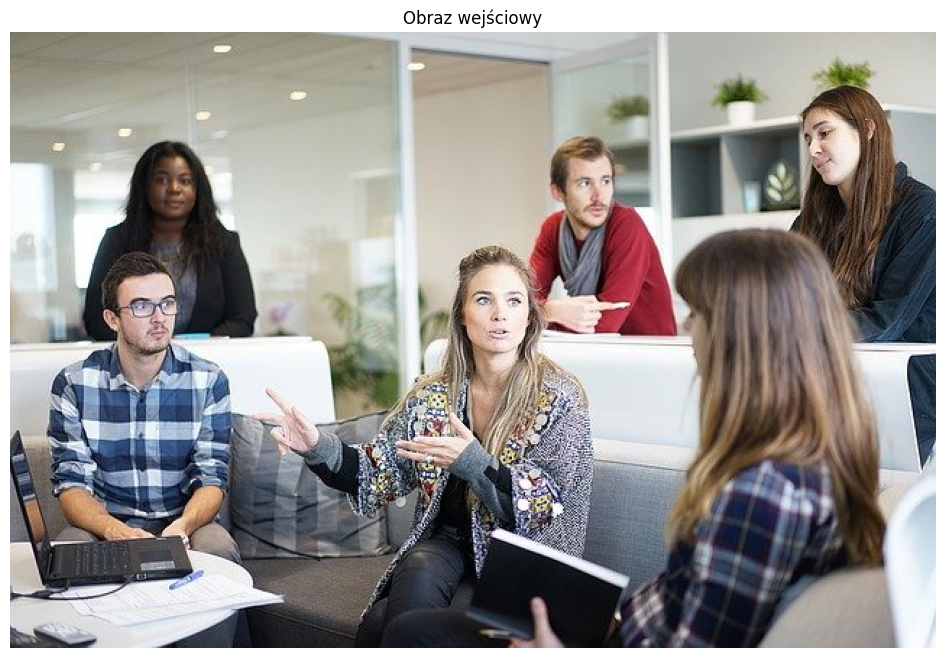

[INFO] Kształt obrazu: (426, 640, 3)


In [ ]:

image_bgr = cv2.imread(IMAGE_PATH)

if image_bgr is None:
    raise ValueError(f"Nie można wczytać obrazu: {IMAGE_PATH}")

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(image_rgb)
plt.axis("off")
plt.title("Obraz wejściowy")
plt.show()

print("[INFO] Kształt obrazu:", image_rgb.shape)


## 7. Inferencja Mask R-CNN

In [ ]:

# Modele Object Detection z TensorFlow Hub oczekują obrazu uint8:
# [batch, height, width, 3]

input_tensor = tf.convert_to_tensor(image_rgb, dtype=tf.uint8)
input_tensor = input_tensor[tf.newaxis, ...]

print("[INFO] Kształt wejścia:", input_tensor.shape)

start = time.time()

raw_output = detector(input_tensor)

elapsed = time.time() - start

print(f"[INFO] Inferencja: {elapsed:.2f} s")
print("[INFO] Klucze wyniku:")
print(sorted(raw_output.keys()))


[INFO] Kształt wejścia: (1, 426, 640, 3)
[INFO] Inferencja: 69.15 s
[INFO] Klucze wyniku:
['anchors', 'box_classifier_features', 'class_predictions_with_background', 'detection_anchor_indices', 'detection_boxes', 'detection_classes', 'detection_masks', 'detection_multiclass_scores', 'detection_scores', 'final_anchors', 'image_shape', 'mask_predictions', 'num_detections', 'num_proposals', 'proposal_boxes', 'proposal_boxes_normalized', 'raw_detection_boxes', 'raw_detection_scores', 'refined_box_encodings', 'rpn_box_encodings', 'rpn_box_predictor_features', 'rpn_features_to_crop', 'rpn_objectness_predictions_with_background']



## 8. Przygotowanie wyników

Mask R-CNN zwraca m.in.:
- `detection_boxes` — ramki `[ymin, xmin, ymax, xmax]` w skali 0–1,
- `detection_classes` — identyfikatory klas COCO,
- `detection_scores` — pewność detekcji,
- `detection_masks` — maski poszczególnych instancji.


In [ ]:

num_detections = int(raw_output["num_detections"][0].numpy())

detections = {}

for key, value in raw_output.items():
    if key == "num_detections":
        continue

    array = value.numpy()

    if array.ndim > 0 and array.shape[0] == 1:
        array = array[0]

    if array.ndim > 0 and array.shape[0] >= num_detections:
        array = array[:num_detections]

    detections[key] = array

detections["detection_classes"] = detections["detection_classes"].astype(np.int64)

print("[INFO] Liczba detekcji:", num_detections)

for key in [
    "detection_boxes",
    "detection_classes",
    "detection_scores",
    "detection_masks",
]:
    if key in detections:
        print(f"{key:20s}: {detections[key].shape}")


[INFO] Liczba detekcji: 100
detection_boxes     : (100, 4)
detection_classes   : (100,)
detection_scores    : (100,)
detection_masks     : (100, 33, 33)


## 9. Tabela wykrytych obiektów

In [ ]:

SCORE_THRESHOLD = 0.50

rows = []

for i, score in enumerate(detections["detection_scores"]):
    score = float(score)

    if score < SCORE_THRESHOLD:
        continue

    class_id = int(detections["detection_classes"][i])

    rows.append({
        "class_id": class_id,
        "class": COCO_CLASSES.get(class_id, f"class_{class_id}"),
        "score": score,
    })

result_df = pd.DataFrame(rows)

if not result_df.empty:
    result_df["score"] = (result_df["score"] * 100).round(2)
    result_df = result_df.rename(columns={"score": "score [%]"})

result_df


,class_id,class,score [%]
0,1,person,99.59
1,1,person,99.37
2,1,person,99.37
3,73,laptop,99.15
4,1,person,99.14
5,1,person,99.08
6,73,laptop,98.96
7,1,person,96.35
8,75,remote,94.46
9,64,potted plant,83.37


## 10. Wizualizacja ramek i masek

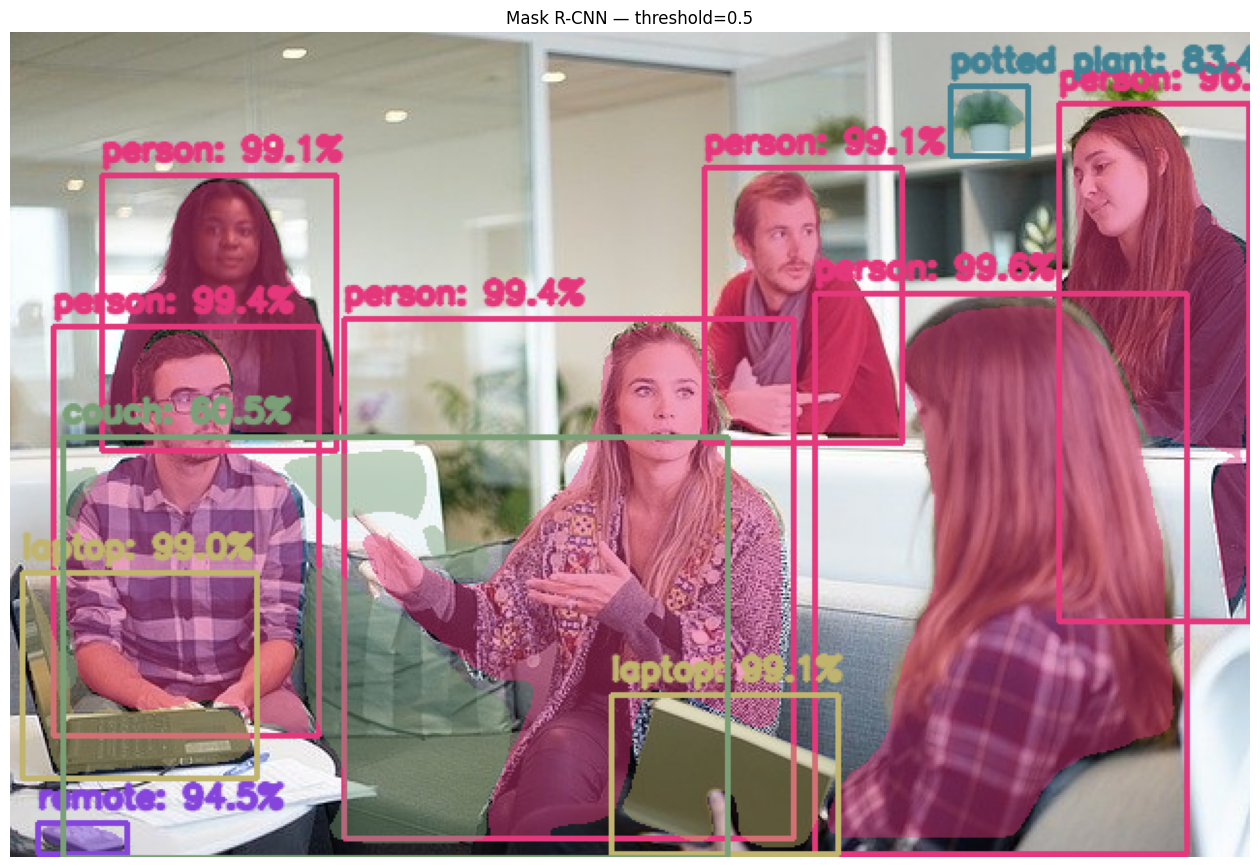

In [ ]:

def class_color(class_id):
    """Powtarzalny kolor RGB dla danej klasy."""
    rng = np.random.default_rng(class_id)
    return rng.integers(30, 230, size=3, dtype=np.uint8)


def visualize_instances(
    image,
    detections,
    class_names,
    score_threshold=0.50,
    mask_threshold=0.50,
    alpha=0.45,
):
    result = image.copy()

    height, width = result.shape[:2]

    boxes = detections["detection_boxes"]
    classes = detections["detection_classes"]
    scores = detections["detection_scores"]
    masks = detections.get("detection_masks")

    for i, score in enumerate(scores):
        score = float(score)

        if score < score_threshold:
            continue

        class_id = int(classes[i])
        label = class_names.get(class_id, f"class_{class_id}")
        color = class_color(class_id)

        ymin, xmin, ymax, xmax = boxes[i]

        x1 = max(0, min(width - 1, int(xmin * width)))
        y1 = max(0, min(height - 1, int(ymin * height)))
        x2 = max(0, min(width, int(xmax * width)))
        y2 = max(0, min(height, int(ymax * height)))

        if x2 <= x1 or y2 <= y1:
            continue

        if masks is not None:
            small_mask = masks[i]

            resized_mask = cv2.resize(
                small_mask.astype(np.float32),
                (x2 - x1, y2 - y1),
                interpolation=cv2.INTER_LINEAR,
            )

            binary_mask = resized_mask >= mask_threshold

            roi = result[y1:y2, x1:x2].copy()

            roi[binary_mask] = (
                roi[binary_mask].astype(np.float32) * (1.0 - alpha)
                + color.astype(np.float32) * alpha
            ).astype(np.uint8)

            result[y1:y2, x1:x2] = roi

        color_tuple = tuple(int(v) for v in color)

        cv2.rectangle(
            result,
            (x1, y1),
            (x2, y2),
            color_tuple,
            2,
        )

        text = f"{label}: {score * 100:.1f}%"

        text_y = max(20, y1 - 8)

        cv2.putText(
            result,
            text,
            (x1, text_y),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            color_tuple,
            2,
            cv2.LINE_AA,
        )

    return result


result_image = visualize_instances(
    image_rgb,
    detections,
    COCO_CLASSES,
    score_threshold=SCORE_THRESHOLD,
)

plt.figure(figsize=(16, 12))
plt.imshow(result_image)
plt.axis("off")
plt.title(f"Mask R-CNN — threshold={SCORE_THRESHOLD}")
plt.show()



## 11. Zmiana progu detekcji

Jeżeli model pokazuje zbyt dużo słabych detekcji, zwiększ:

```python
SCORE_THRESHOLD = 0.70
```

Jeżeli pomija obiekty, możesz zmniejszyć próg, np.:

```python
SCORE_THRESHOLD = 0.30
```

Następnie uruchom ponownie komórkę z wizualizacją.



## Co zostało zmienione względem starego ćwiczenia?

Usunięto:
- `%tensorflow_version 1.x`,
- `tensorflow.compat.v1`,
- repozytorium Matterport `Mask_RCNN`,
- `mrcnn.model`,
- `keras.engine`,
- `mask_rcnn_coco.h5`,
- klasę `InferenceConfig(coco.CocoConfig)`.

Zastąpiono je:
- TensorFlow 2,
- standardowym `SavedModel`,
- pretrenowanym Mask R-CNN z TensorFlow Hub,
- własną prostą wizualizacją masek i ramek.

Dzięki temu notebook nie zależy od API Keras 2 / TensorFlow 1.x i jest przygotowany
do użycia w aktualnym Google Colab.
